In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2"
from transformers import AutoModelForCausalLM, AutoTokenizer

model_path = "/home/lym/data1/LLM-model/meta-llama/Meta-Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    device_map="auto",
    torch_dtype="auto",
    attn_implementation="eager",
)
model.eval()

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((4096,), eps=1e-05)
    (rotary_

In [2]:
import sys
sys.path.append("/home/lym/LLM-Research/Attention/Graph_Attention/SLASH/src/slash")
import torch
import numpy as np
from utils import (
    get_token_spans,
    compute_global_span,
    build_local_spans,
    build_sawtooth_mask,
    extract_roi_from_attn
)

# sample_input = "Determine whether or not there is a cycle in an undirected graph. In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. Given a graph, you need to output Yes or No, indicating whether there is a cycle in the graph. Q: The nodes are numbered from 0 to 16, and the edges are: (0, 9) (0, 3) (0, 5) (1, 6) (1, 4) (1, 9) (2, 4) (2, 7) (3, 13) (3, 4) (3, 14) (3, 11) (3, 8) (4, 12) (4, 8) (4, 14) (4, 6) (5, 6) (5, 13) (5, 8) (5, 10) (5, 9) (6, 11) (6, 15) (6, 8) (7, 14) (7, 15) (9, 13) (9, 16) (10, 16) (10, 15) (10, 13) (11, 13) (12, 15) (13, 15) (14, 16). Is there a cycle in this graph?"
# sample_input = "Determine whether or not there is a cycle in an undirected graph. In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. Given a graph, you need to output Yes or No, indicating whether there is a cycle in the graph. Q: The nodes are numbered from 0 to 11, and the edges are: (0, 6) (0, 2) (0, 3) (0, 10) (0, 7) (0, 11) (1, 6) (1, 3) (1, 2) (1, 4) (1, 11) (1, 7) (1, 8) (1, 9) (2, 4) (2, 7) (2, 6) (2, 8) (2, 10) (2, 11) (2, 9) (2, 5) (3, 11) (3, 5) (3, 6) (3, 4) (3, 8) (4, 11) (4, 7) (4, 10) (4, 9) (4, 6) (5, 10) (5, 7) (5, 9) (5, 11) (5, 8) (6, 11) (6, 9) (6, 7) (6, 10) (6, 8) (7, 8) (7, 11) (7, 9) (7, 10) (8, 9) (8, 10) (9, 11) (9, 10) (10, 11). Is there a cycle in this graph?"
sample_input = "Determine whether or not there is a cycle in an undirected graph. In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. Given a graph, you need to output Yes or No, indicating whether there is a cycle in the graph. Q: The nodes are numbered from 0 to 11, and the edges are: (0, 3) (0, 10) (0, 7) (0, 5) (0, 8) (0, 11) (0, 2) (0, 1) (0, 4) (1, 6) (1, 9) (1, 2) (1, 4) (1, 7) (1, 8) (1, 5) (1, 10) (2, 5) (2, 9) (2, 10) (2, 7) (2, 3) (2, 8) (2, 11) (3, 10) (3, 4) (3, 6) (3, 5) (3, 7) (4, 9) (4, 5) (4, 11) (4, 10) (4, 6) (4, 7) (5, 8) (5, 10) (5, 11) (5, 6) (5, 9) (6, 11) (6, 7) (6, 9) (7, 11) (7, 8) (7, 9) (7, 10) (8, 9) (8, 10) (9, 11) (9, 10) (10, 11). Is there a cycle in this graph?"
# sample_input = "Determine whether or not there is a cycle in an undirected graph. In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. Given a graph, you need to output Yes or No, indicating whether there is a cycle in the graph. Q: The nodes are numbered from 0 to 14, and the edges are: (0, 9) (0, 4) (0, 8) (0, 10) (0, 7) (0, 1) (0, 13) (0, 14) (0, 6) (0, 2) (0, 3) (0, 5) (0, 12) (1, 4) (1, 9) (1, 14) (1, 3) (1, 2) (1, 12) (1, 8) (1, 11) (1, 6) (1, 13) (1, 7) (1, 5) (1, 10) (2, 9) (2, 12) (2, 14) (2, 4) (2, 11) (2, 7) (2, 5) (2, 6) (2, 8) (2, 13) (2, 10) (3, 8) (3, 5) (3, 12) (3, 6) (3, 11) (3, 9) (3, 10) (3, 13) (3, 7) (3, 4) (3, 14) (4, 7) (4, 10) (4, 9) (4, 8) (4, 12) (4, 6) (4, 13) (4, 14) (4, 11) (5, 8) (5, 12) (5, 7) (5, 10) (5, 14) (5, 9) (5, 11) (5, 6) (5, 13) (6, 8) (6, 9) (6, 13) (6, 10) (6, 12) (6, 7) (6, 14) (6, 11) (7, 12) (7, 9) (7, 8) (7, 11) (7, 10) (7, 14) (7, 13) (8, 13) (8, 10) (8, 9) (8, 11) (8, 14) (8, 12) (9, 10) (9, 13) (9, 11) (10, 11) (10, 12) (10, 13) (10, 14) (11, 13) (11, 12) (11, 14) (12, 13) (12, 14). Is there a cycle in this graph?"
layer, head = 12, 24

enc = tokenizer(
    sample_input,
    return_tensors="pt",
    truncation=True,
    max_length=800,
).to(model.device)
with torch.no_grad():
    out = model(enc.input_ids, output_attentions=True, use_cache=False)
attn_np = np.stack(
    [a[0].to(torch.float32).detach().cpu().numpy() for a in out.attentions],
    axis=0
) 
print(f"attn_np shape: {attn_np.shape}")

full_attn = attn_np[layer, head]

spans = get_token_spans(sample_input, tokenizer)
print(spans)
g_start, g_end, span_len, spans_sorted = compute_global_span(spans)
local_spans = build_local_spans(g_start, spans_sorted)
ideal_mask = build_sawtooth_mask(span_len, local_spans)

roi_attn = full_attn[g_start:g_end + 1, g_start:g_end + 1]
print(f"roi_attn shape: {roi_attn.shape}")

del out, attn_np
torch.cuda.empty_cache()

attn_np shape: (32, 32, 401, 401)
[{'tok_start': 81, 'tok_end': 134}, {'tok_start': 135, 'tok_end': 182}, {'tok_start': 183, 'tok_end': 224}, {'tok_start': 225, 'tok_end': 254}, {'tok_start': 255, 'tok_end': 290}, {'tok_start': 291, 'tok_end': 320}, {'tok_start': 321, 'tok_end': 338}, {'tok_start': 339, 'tok_end': 362}, {'tok_start': 363, 'tok_end': 374}, {'tok_start': 375, 'tok_end': 386}, {'tok_start': 387, 'tok_end': 392}]
roi_attn shape: (312, 312)


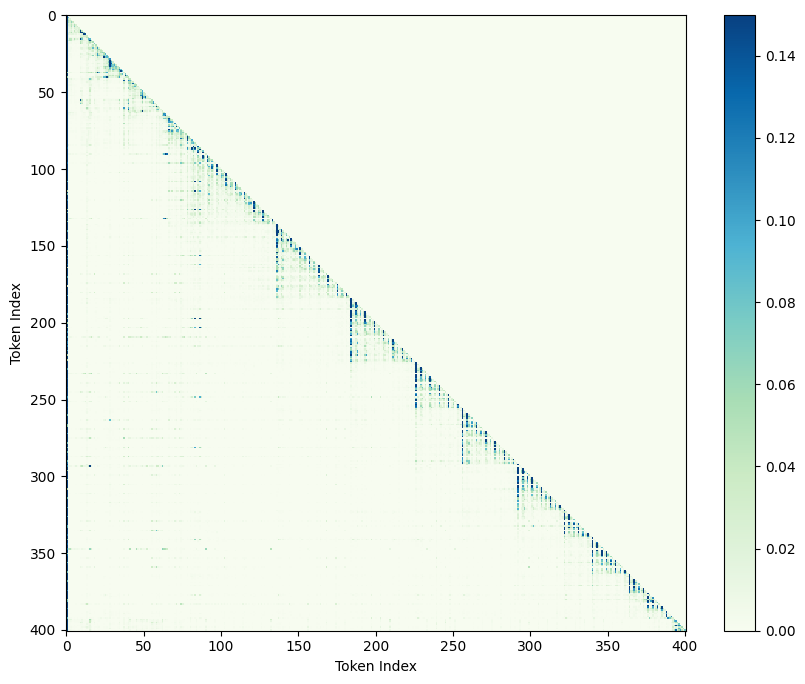

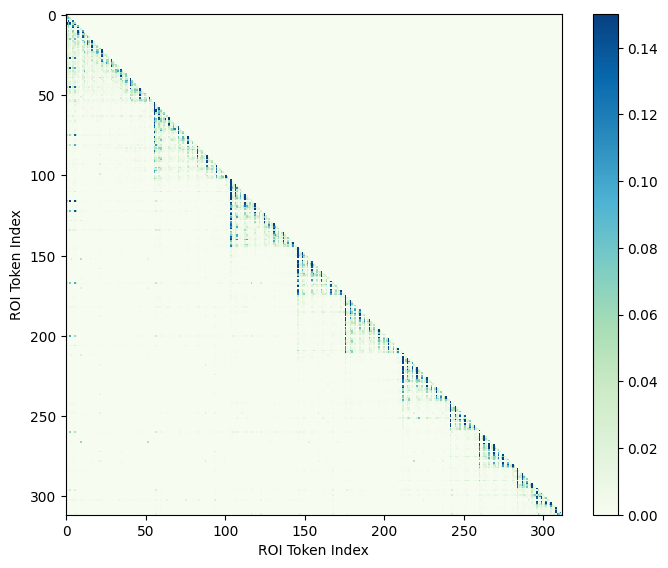

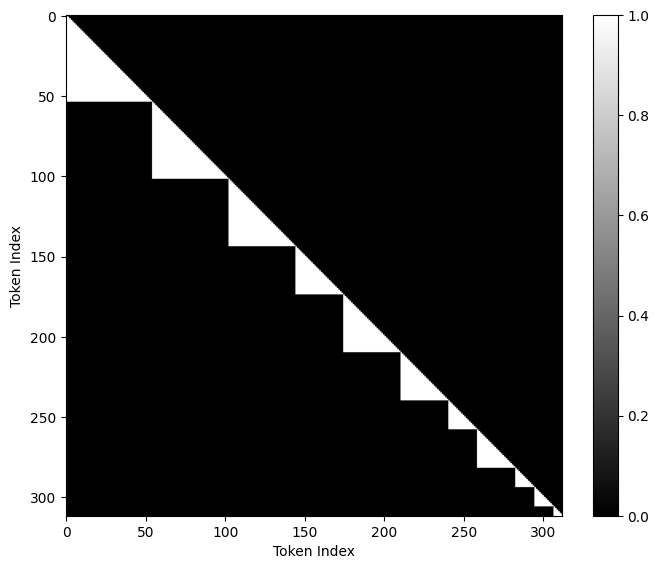

In [3]:
import matplotlib.pyplot as plt

# 绘制 full_attn 热力图
# full_attn[:, 0] = 0
plt.figure(figsize=(10, 8))
# plt.title("full_attn Heatmap")
plt.imshow(full_attn, aspect='auto', cmap='GnBu', interpolation='nearest', vmax=0.15)
plt.colorbar()
plt.xlabel("Token Index")
plt.ylabel("Token Index")
plt.show()

# 绘制 roi_attn 热力图
plt.figure(figsize=(8, 6.5))
# plt.title("roi_attn Heatmap")
plt.imshow(roi_attn, aspect='auto', cmap='GnBu', interpolation='nearest', vmax=0.15)
plt.colorbar()
plt.xlabel("ROI Token Index")
plt.ylabel("ROI Token Index")
plt.show()

# 绘制 ideal_mask 热力图
plt.figure(figsize=(8, 6.5))
# plt.title("ideal_mask Heatmap")
plt.imshow(ideal_mask, aspect='auto', cmap='gray')
plt.colorbar()
plt.xlabel("Token Index")
plt.ylabel("Token Index")
plt.show()

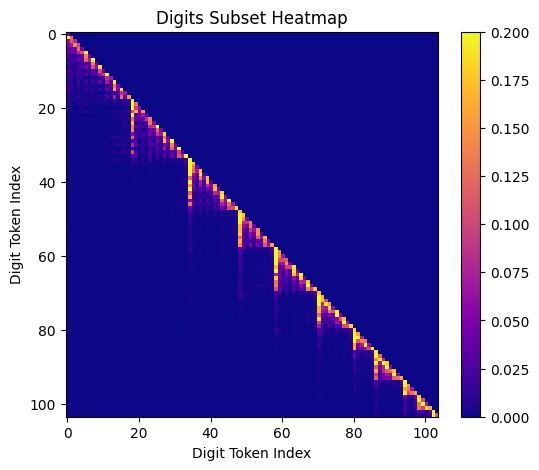

In [4]:
import re
from matplotlib.colors import LinearSegmentedColormap

# 1. 提取所有数字字符串
numbers = sorted(set(map(int, re.findall(r'\d+', sample_input))))
number_tokens = [str(n) for n in numbers]

# 2. 获取roi区域的token ids
enc_roi_ids = enc.input_ids[0, g_start:g_end+1].tolist()

# 3. 获取所有数字token的id（只取第一个token，适用于单token数字）
digit_token_ids = [tokenizer.encode(num, add_special_tokens=False)[0] for num in number_tokens]

# 4. 找到这些token id在roi中的索引
num_token_indices = [i for i, tid in enumerate(enc_roi_ids) if tid in digit_token_ids]

# 5. 提取对应行列的子矩阵
roi_digits_attn = roi_attn[np.ix_(num_token_indices, num_token_indices)]

custom_cmap = LinearSegmentedColormap.from_list('my_cmap', ['#f2f2f2', '#be5c37'])
soft_red = LinearSegmentedColormap.from_list(
    'soft_red', ['#fff5f0', '#fcbba1', '#e74c3c']
)
soft_orange = LinearSegmentedColormap.from_list(
    'soft_orange', ['#fff7ec', '#fdcc8a', '#ff9800']
)
soft_green = LinearSegmentedColormap.from_list(
    'soft_green', ['#f7fcf5', '#b2e2b4', '#41b883']
)
soft_blue = LinearSegmentedColormap.from_list(
    'soft_blue', ['#f7fbff', '#a6c8e0', '#3498db']
)
custom_cmap = LinearSegmentedColormap.from_list('my_cmap', ["#dbe0e1", '#ebbfc2', '#e28187'])
# custom_cmap = LinearSegmentedColormap.from_list('my_cmap', ['#fbf9fa', '#afb7db', '#507aaf'])
# 6. 绘制更小的子集热力图
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))
plt.title("Digits Subset Heatmap")
plt.imshow(roi_digits_attn, aspect='auto', cmap='plasma', interpolation='nearest', vmax=0.2)
plt.colorbar()
plt.xlabel("Digit Token Index")
plt.ylabel("Digit Token Index")
plt.show()


Sequential_maps = ['Greys', 'Purples', 'Blues', 'Greens', 'Oranges', 'Reds',
    'YlOrBr', 'YlOrRd', 'OrRd', 'PuRd', 'RdPu', 'BuPu',
    'GnBu', 'PuBu', 'YlGnBu', 'PuBuGn', 'BuGn', 'YlGn']
# OrRd, GnBu

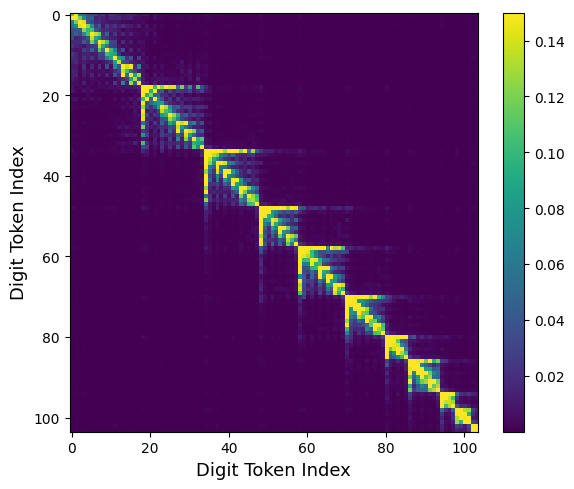

[320, 15, 11, 220, 18, 8, 320, 15, 11, 220, 605, 8, 320, 15, 11, 220, 22, 8, 320, 15, 11, 220, 20, 8, 320, 15, 11, 220, 23, 8, 320, 15, 11, 220, 806, 8, 320, 15, 11, 220, 17, 8, 320, 15, 11, 220, 16, 8, 320, 15, 11, 220, 19, 8, 320, 16, 11, 220, 21, 8, 320, 16, 11, 220, 24, 8, 320, 16, 11, 220, 17, 8, 320, 16, 11, 220, 19, 8, 320, 16, 11, 220, 22, 8, 320, 16, 11, 220, 23, 8, 320, 16, 11, 220, 20, 8, 320, 16, 11, 220, 605, 8, 320, 17, 11, 220, 20, 8, 320, 17, 11, 220, 24, 8, 320, 17, 11, 220, 605, 8, 320, 17, 11, 220, 22, 8, 320, 17, 11, 220, 18, 8, 320, 17, 11, 220, 23, 8, 320, 17, 11, 220, 806, 8, 320, 18, 11, 220, 605, 8, 320, 18, 11, 220, 19, 8, 320, 18, 11, 220, 21, 8, 320, 18, 11, 220, 20, 8, 320, 18, 11, 220, 22, 8, 320, 19, 11, 220, 24, 8, 320, 19, 11, 220, 20, 8, 320, 19, 11, 220, 806, 8, 320, 19, 11, 220, 605, 8, 320, 19, 11, 220, 21, 8, 320, 19, 11, 220, 22, 8, 320, 20, 11, 220, 23, 8, 320, 20, 11, 220, 605, 8, 320, 20, 11, 220, 806, 8, 320, 20, 11, 220, 21, 8, 320, 20, 11, 2

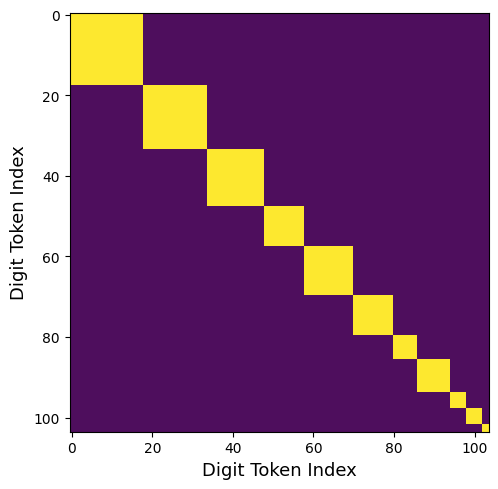

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import re

# 1. 对称化注意力子矩阵
roi_digits_attn_sym = (roi_digits_attn + roi_digits_attn.T)

plt.figure(figsize=(6, 5))
# plt.title("Symmetric Digits Attention", fontsize=16)
plt.imshow(roi_digits_attn_sym, aspect='auto', cmap='viridis', interpolation='nearest', vmax=0.15)
plt.colorbar()
plt.xlabel("Digit Token Index", fontsize=13)
plt.ylabel("Digit Token Index", fontsize=13)
plt.tight_layout()
plt.show()


# 假设 num_token_indices, roi_digits_attn_sym 已有
# 1. 获取 roi 区域所有数字token的顺序列表
enc_roi_ids = enc.input_ids[0, g_start:g_end+1].tolist()
roi_digits_token_list = []
for tid in num_token_indices:
    token_str = tokenizer.decode([enc_roi_ids[tid]]).strip()
    roi_digits_token_list.append(token_str)

N = len(roi_digits_token_list)
gt = np.zeros((N, N), dtype=int)

print(enc_roi_ids)
print(local_spans)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

N = len(num_token_indices)
gt = np.zeros((N, N), dtype=int)

# num_token_indices 是数字token在roi中的索引
for span_start, span_end in local_spans:
    # 找到属于当前span的数字token子集的索引
    indices_in_span = [k for k, idx in enumerate(num_token_indices) if span_start <= idx <= span_end]
    for i in indices_in_span:
        for j in indices_in_span:
            gt[i, j] = 1

plt.figure(figsize=(6,5))
# plt.title("Local Span-based Adjacency", fontsize=16)
# plt.imshow(gt, aspect='auto', cmap='viridis', interpolation='nearest')
plt.imshow(gt, cmap='viridis', interpolation='nearest', alpha=0.95)
# sns.heatmap(gt, cmap='viridis', linewidths=0.01, linecolor='gray', square=True, cbar=True)
# plt.colorbar(fraction=0.046, pad=0.04)
plt.xlabel("Digit Token Index", fontsize=13)
plt.ylabel("Digit Token Index", fontsize=13)
plt.tight_layout()
plt.show()